# ALTRA data scRNA psedubulk in Python - deep clean data
## make psedubulk data by AIFI l3 labels for all aims

In [1]:
import h5py
import scipy.sparse as scs
import pandas as pd
import anndata
import os
import glob
from matplotlib import pyplot as plt
import seaborn as sns
#import numpy as np
from scipy.stats import median_abs_deviation
import scanpy as sc
import random
import decoupler as dc
import hisepy
import re
from datetime import date

In [2]:
dc.__version__

'1.8.0'

In [3]:
# sc.settings.n_jobs = 58

In [3]:
# define some color patterns for plotting
nejm_color = ["#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF",
              "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF"]
jama_color = ["#374E55FF", "#DF8F44FF", "#00A1D5FF",
              "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF"]

In [4]:
# define working path
data_path = '/home/jupyter//07-pseudobulk2/data/'
meta_path = '/home/jupyter/07-pseudobulk2/data/'
fig_path = '/home/jupyter/07-pseudobulk2/results//'
output_path = '/home/jupyter/07-pseudobulk2/results/'
# os.mkdir(fig_path)
# os.mkdir(output_path)
# define a project name
proj_name = 'UP1_scRNA_AIFI_L3_Pseudobulk_'
# sc.set_figure_params(fig_path)
sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [5]:
### make an empty list of out files to store for certpro upload
out_files = []

## Helper functions

In [6]:
def cache_uuid_path(uuid):
    cache_path = '/home/jupyter/cache/{u}'.format(u = uuid)
    if not os.path.isdir(cache_path):
        hise_res = hisepy.reader.cache_files([uuid])
    filename = os.listdir(cache_path)[0]
    cache_file = '{p}/{f}'.format(p = cache_path, f = filename)
    return cache_file

In [7]:
def sort_adata_uuid(uuid, sort_cols = ['AIFI_L2', 'sample.sampleKitGuid']):
    cache_file = cache_uuid_path(uuid)
    adata = sc.read_h5ad(cache_file)
    obs = adata.obs
    obs = obs.sort_values(sort_cols)
    adata = adata[obs.index]
    adata.write_h5ad(cache_file)

In [8]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))

In [9]:
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
    rand_str = '-'.join(rand_el)
    return rand_str

## Identify files for use in HISE

In [10]:
search_id ='moscovium-iron-fermium'

In [11]:
ps_df = hisepy.list_files_in_project_store('Dyna_IHandA')
ps_df = ps_df[['id', 'name']]

In [12]:
search_df = ps_df[ps_df['name'].str.contains(search_id)]
search_df = search_df.sort_values('name')

In [13]:
h5ad_df = search_df[search_df['name'].str.contains('.h5ad')]

In [14]:
h5ad_df

,id,name
146,ffbfcc3d-253f-4f15-8821-0c912e7dddeb,moscovium-iron-fermium/up1_dc_sample_selection...


In [15]:
h5ad_uuids = {}
for i in range(h5ad_df.shape[0]):
    fn = h5ad_df['name'].tolist()[i]
    group_name = re.sub('.+pbmc_', '', fn)
    group_name = re.sub('_init.+', '', group_name)
    h5ad_uuids[group_name] = h5ad_df['id'].tolist()[i]

In [16]:
h5ad_uuids

{'moscovium-iron-fermium/up1_dc_sample_selection_combined_adata_2024-08-29.h5ad': 'ffbfcc3d-253f-4f15-8821-0c912e7dddeb'}

## Download and sort .h5ad files

Sorting the .h5ad files by AIFI_L3_new will make reading each cell type much faster by placing cells of the same type next to each other in the sparse matrix.

In [ ]:
# run once
for uuid in h5ad_uuids.values():
    sort_adata_uuid(uuid, sort_cols = ['AIFI_L3'])

# make pseudobulk object based on the cell types and samples

In [17]:
# load the deep clean data
joint_adata_fl = sc.read_h5ad('/home/jupyter/output/up1_dc_sample_selection_combined_adata_2024-08-29.h5ad')

In [18]:
joint_adata_fl

AnnData object with n_obs × n_vars = 3743041 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2'
    obsm: 'X_pca', 'X_pca_harmony', 'X

In [19]:
# doouble check the raw counts data is stored in X, if not restore
joint_adata_fl.X[100:120, 500:520].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0],
       [0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0],
       [0, 0, 0, 1, 2, 0, 0, 0, 0,

In [20]:
joint_adata_fl.raw[100:120, 500:520].toarray()

AttributeError: 'NoneType' object has no attribute 'X'

In [21]:
# restore raw layer to .X default and check 
joint_adata_fl = joint_adata_fl.raw.to_adata()
joint_adata_fl.X[100:120, 500:520].toarray()

AttributeError: 'NoneType' object has no attribute 'to_adata'

## Pseudobulk by cell type and samples

In [33]:
joint_adata_fl

AnnData object with n_obs × n_vars = 3743041 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'specimens.specimenType', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2'
    obsm: 'X_pca', 'X_pca_harmony', 'X

In [23]:
# define the cell type column
# cell_type_col = 'celltypist_majority_label_pbmc'
cell_type_col = 'AIFI_L3'

In [24]:
joint_adata_fl.obs.groupby(cell_type_col).size()

/tmp/ipykernel_124703/4128763830.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  joint_adata_fl.obs.groupby(cell_type_col).size()


AIFI_L3
ASDC                               1301
Activated memory B cell            1745
Adaptive NK cell                  29815
BaEoMaP cell                        139
C1Q+ CD16 monocyte                 3895
                                  ...  
SOX4+ naive CD8 T cell            26703
Transitional B cell               53456
Type 2 polarized memory B cell     6449
cDC1                               1645
pDC                               21701
Length: 70, dtype: int64

In [35]:
# use decoupler to make pseudobulk for all samples
# remove samples with less than 10 cells or 1000 total gene counts
adata_pb = dc.get_pseudobulk(joint_adata_fl, sample_col="sample.sampleKitGuid",
                             groups_col=cell_type_col)# min_cells=10, min_counts=1000,
                             #mode='sum')

In [36]:
adata_pb

AnnData object with n_obs × n_vars = 11912 × 30316
    obs: 'sample.sampleKitGuid', 'AIFI_L3', 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [28]:
# check cell type size
adata_pb.obs.groupby([cell_type_col]).size()

AIFI_L3
ASDC                               33
Activated memory B cell            61
Adaptive NK cell                  196
C1Q+ CD16 monocyte                147
CD14+ cDC2                        211
                                 ... 
SOX4+ naive CD8 T cell            216
Transitional B cell               218
Type 2 polarized memory B cell    207
cDC1                               54
pDC                               218
Length: 68, dtype: int64

<Axes: >

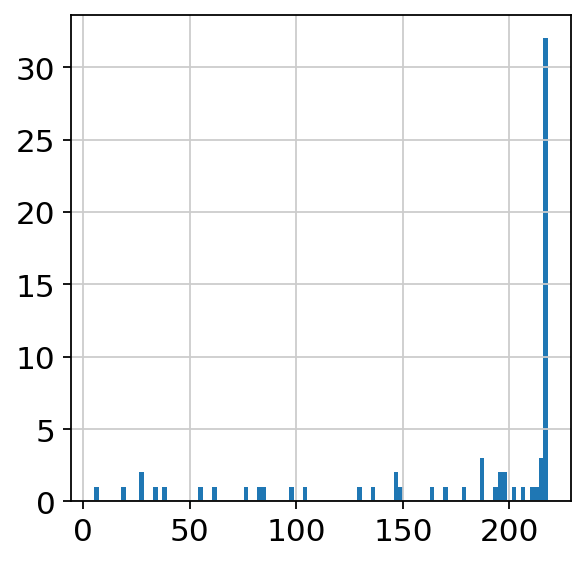

In [29]:
adata_pb.obs.groupby([cell_type_col]).size().hist(bins=100)

<Axes: >

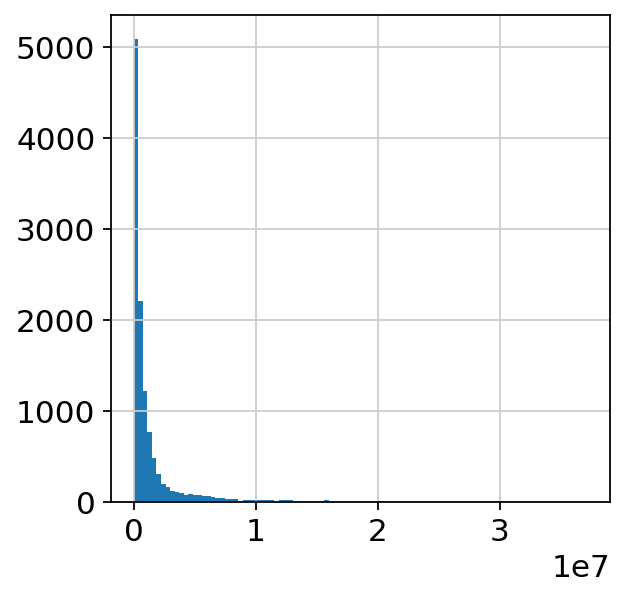

In [30]:
adata_pb.obs['psbulk_counts'].hist(bins=100)

<Axes: >

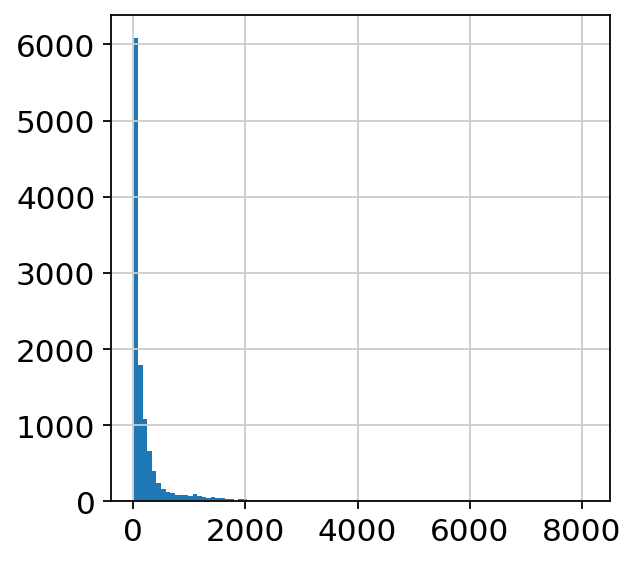

In [31]:
adata_pb.obs['psbulk_n_cells'].hist(bins=100)

In [32]:
# Convert all values in adata_pb.obs to strings to avoid any type conversion issues while saving.
adata_pb.obs = adata_pb.obs.astype(str)

In [33]:
# check to make sure the counts are stored in X
adata_pb.X

array([[ 10.,   0.,   0., ...,   2.,   8.,   5.],
       [  8.,   0.,   0., ...,   0.,  16.,   0.],
       [  6.,   1.,   0., ...,   2.,  10.,   1.],
       ...,
       [277.,   5.,   0., ...,  15.,  56.,  18.],
       [127.,   6.,   0., ...,   3.,  25.,  15.],
       [104.,   3.,   0., ...,   7.,  37.,  10.]], dtype=float32)

In [35]:
adata_pb.layers['counts'] = adata_pb.X.copy()

In [36]:
adata_pb

AnnData object with n_obs × n_vars = 11912 × 30316
    obs: 'sample.sampleKitGuid', 'AIFI_L3', 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props', 'counts'

In [37]:
out_file = output_path+proj_name+'celltype_IH_l3_psbulk.h5ad'
out_file

'/home/jupyter/07-pseudobulk2/results/UP1_scRNA_AIFI_L3_Pseudobulk_celltype_IH_l3_psbulk.h5ad'

In [38]:
# save the h5ad file
adata_pb.write_h5ad(out_file)

In [39]:
# load the h5ad file
adata_pb = sc.read_h5ad(out_file)

In [40]:
adata_pb

AnnData object with n_obs × n_vars = 11912 × 30316
    obs: 'sample.sampleKitGuid', 'AIFI_L3', 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'counts', 'psbulk_props'

## seperate the psudobulk data into three aims

In [53]:
adata_pb

AnnData object with n_obs × n_vars = 11912 × 30316
    obs: 'sample.sampleKitGuid', 'AIFI_L3', 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'specimens.specimenGuid', 'file.id', 'file.batchID', 'subset_grp', 'predicted_doublet', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'counts', 'psbulk_props'

In [65]:
# load metadata
aim1_meta = pd.read_csv(
    meta_path + 'ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv')
aim2_meta = pd.read_csv(
    meta_path + 'ALTRA_RA_Aim2_ALTRA_early_RA_vs_HCs_scrna_metadata.csv')
aim3_meta = pd.read_csv(
    meta_path + 'ALTRA_RA_Aim3_ALTRA_converters_longitudinal_scrna_metadata.csv')
lab_meta = pd.read_csv( meta_path + 
    '2023-11-22_ALTRA_Metadata_labs.csv')

In [66]:
##### remove samples past -750 DTC for consistency
aim3_meta[aim3_meta['days_to_conversion'] >= -750]

,lastUpdated,sample.id,sample.bridgingControl,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,file.id,...,cohort.cohortGuid,file.userTags.details,file.userTags.group,file.userTags.name,file.userTags.origin,file.userTags.other,file.userTags.version,days_to_conversion,status,age
0,2023-11-09 02:52:35.494,d4ea69f7-37a6-4e91-839a-e93ab80bbfc5,False,KT00493,Flu Year 2 Day 90,N/A - Flu-Series Timepoint Only,2021-02-01,488,Rheumatoid arthritis,8e3f3734-d60c-4716-8c36-6bff6eb9acd9,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,-127,pre,23
1,2023-11-09 02:52:35.494,fa01b4a2-b150-4ac9-9ab8-4c63861fefad,False,KT02135,Flu Year 3 Stand-Alone,RA Conversion,2021-06-01,615,Rheumatoid arthritis,251b30f7-5db3-4f25-9040-6563d8855205,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,0,conversion,23
2,2023-11-09 02:52:35.494,7f5a284a-b300-4bf3-ac67-8d9d52db97e6,False,KT00440,Flu Year 2 Day 0,N/A - Flu-Series Timepoint Only,2020-10-01,355,Rheumatoid arthritis,0a3c3ce1-2006-4a07-a086-362a1eda303b,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,-260,pre,22
3,2023-11-09 02:52:35.494,3d176e60-ec9e-4745-9c5b-e019b39b41d8,False,KT00227,Flu Year 2 Stand-Alone,N/A - Flu-Series Timepoint Only,2020-07-01,271,Rheumatoid arthritis,84844967-a3c6-42db-b8a8-f0c255d4df60,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,-344,pre,22
4,2023-11-09 02:52:35.494,145f6021-9749-40af-b7c5-612e477776b6,False,KT00099,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,2020-01-01,99,Rheumatoid arthritis,b7601874-9628-498a-a1a9-3d3a1d9de2e6,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,-516,pre,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,2023-11-09 02:52:35.494,13a662c1-87ae-475d-a8fa-686b98759a8b,False,KT00118,Flu Year 1 Stand-Alone,N/A - Flu-Series Timepoint Only,2020-08-01,0,Rheumatoid arthritis,e9740f82-2c03-49cf-bd22-6665ee8d7f42,...,SD1,NaN,NaN,NaN,NaN,NaN,NaN,-204,pre,31
64,2023-11-09 02:52:35.494,cdf80d0d-3221-43b1-a5ae-6ad9045e222b,False,KT00105,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2020-12-01,112,Rheumatoid arthritis,15e214ab-7230-4df9-beca-fce1c8c51f66,...,SD1,NaN,NaN,NaN,NaN,NaN,NaN,-92,pre,31
65,2023-11-20T19:04:58.033Z,dc6588a9-ef3c-45be-8308-0f96fe5b4686,False,KT02975,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,2022-02-01T00:00:00Z,279,Rheumatoid arthritis,d30ec314-b75c-4644-a1ff-f36d371a438a,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,0,conversion,75
66,2023-11-20T19:04:58.033Z,b606576c-0bad-4756-97b7-f275137c9d64,False,KT00057,Flu Year 1 Day 0,N/A - Flu-Series Timepoint Only,2019-10-01T00:00:00Z,0,Rheumatoid arthritis,5e3ce6b9-95a9-4893-8123-b9b7a5d5c9d8,...,CU1,NaN,NaN,NaN,NaN,NaN,NaN,-615,pre,21


In [67]:
aim3_meta = aim3_meta[aim3_meta['days_to_conversion'] >= -750]
len(aim3_meta)

62

In [68]:
# lab_meta.columns.tolist()

In [69]:
# seperate the aims
aim1_pb = adata_pb[adata_pb.obs[
    'sample.sampleKitGuid'].isin(aim1_meta['sample.sampleKitGuid'])].copy()
aim2_pb = adata_pb[adata_pb.obs[
    'sample.sampleKitGuid'].isin(aim2_meta['sample.sampleKitGuid'])].copy()
aim3_pb = adata_pb[adata_pb.obs[
    'sample.sampleKitGuid'].isin(aim3_meta['sample.sampleKitGuid'])].copy()

In [70]:
# add back the metadata needed for each aims
meta_cols = ['sample.sampleKitGuid',
              'anti_ccp3_finalCombined', 'BMI', 'CMV_Status_Subj']
              
aim1_pb.obs = aim1_pb.obs.merge(
    lab_meta[meta_cols],
    how='left', on='sample.sampleKitGuid')
# add back the metadata needed for each aims
aim2_pb.obs = aim2_pb.obs.merge(
    lab_meta[meta_cols],
    how='left', on='sample.sampleKitGuid')
# add back the metadata needed for each aims
aim3_pb.obs = aim3_pb.obs.merge(
    lab_meta[['sample.sampleKitGuid', 'anti_ccp3_finalCombined',
              'CMV_Status_Subj']],
    how='left', on='sample.sampleKitGuid')

In [71]:
aim1_pb

AnnData object with n_obs × n_vars = 4061 × 29896
    obs: 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'AIFI_L3', 'doublets_manual', 'AIFI_L3_new', 'Status_Xsec', 'Status_Long', 'Age2023', 'days_to_conversion', 'age_conv', 'bmi_conv', 'psbulk_n_cells', 'psbulk_counts', 'anti_ccp3_finalCombined', 'BMI', 'CMV_Status_Subj'
    layers: 'counts', 'psbulk_props'

In [72]:
aim2_pb

AnnData object with n_obs × n_vars = 2976 × 29896
    obs: 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'AIFI_L3', 'doublets_manual', 'AIFI_L3_new', 'Status_Xsec', 'Status_Long', 'Age2023', 'days_to_conversion', 'age_conv', 'bmi_conv', 'psbulk_n_cells', 'psbulk_counts', 'anti_ccp3_finalCombined', 'BMI', 'CMV_Status_Subj'
    layers: 'counts', 'psbulk_props'

In [73]:
aim3_pb

AnnData object with n_obs × n_vars = 3422 × 29896
    obs: 'batch_id', 'hto_barcode', 'hto_category', 'pbmc_sample_id', 'pool_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'AIFI_L3', 'doublets_manual', 'AIFI_L3_new', 'Status_Xsec', 'Status_Long', 'Age2023', 'days_to_conversion', 'age_conv', 'bmi_conv', 'psbulk_n_cells', 'psbulk_counts', 'anti_ccp3_finalCombined', 'CMV_Status_Subj'
    layers: 'counts', 'psbulk_props'

In [74]:
len(aim1_pb.obs['sample.sampleKitGuid'].unique())

76

In [75]:
# save the h5ad file by aims
aim1_pb.write_h5ad(output_path+proj_name+'_AIM1_psbulk.h5ad')
aim2_pb.write_h5ad(output_path+proj_name+'_AIM2_psbulk.h5ad')
aim3_pb.write_h5ad(output_path+proj_name+'_AIM3_psbulk.h5ad')

## loop to make cell type specific counts table and metadata

In [47]:
def generate_pseudobulk_data(adata_pb, output_path, cell_type_col): # Temi: did not split by aim so I took it out - , aim):
    """
    Generate pseudobulk data for each cell type in the provided AnnData object.

    Parameters:
        adata_pb (AnnData): The AnnData object containing the single-cell RNA-seq data.
        output_path (str): The path to the directory where the pseudobulk data will be saved.
        cell_type_col (str): The name of the column in the `obs` attribute of `adata_pb` that contains the cell type information.

    Returns:
        None
    """
    for cell_type in adata_pb.obs[cell_type_col].unique():
        print("generating pseudobulk data for " + cell_type)
        adata_pb_sub = adata_pb[adata_pb.obs[cell_type_col] == cell_type].copy()
        sample_number = len(adata_pb_sub.obs['sample.sampleKitGuid'].unique())
        # filter pseudobulk data by proportion expression
        adata_pb_sub = adata_pb_sub[:, dc.filter_by_prop(
            adata_pb_sub, min_prop=0.1, min_smpls=sample_number/3)].copy()
        # filter pseudobulk data by gene counts
        # genes_keep = dc.filter_by_expr(
        #     adata_pb_sub, min_count=10, min_total_count=15) #temi group='Status_Xsec'
        print(len(adata_pb_sub.var))
        #print("remaining " + len(adata_pb_sub.var) + ' genes in ' + cell_type)
        #adata_pb_sub = adata_pb_sub[:, genes_keep].copy()
        # output counts and metadata file
        # save the counts data
        adata_pb_sub_counts = pd.DataFrame(index=adata_pb_sub.obs.index, columns=adata_pb_sub.var.index,
                                           data=adata_pb_sub.layers['counts'])
        adata_pb_sub_counts.to_csv(output_path+proj_name + '_' + "_" +
                                   cell_type + '_psbulk_counts.tsv', sep="\t")
        # save the meta data
        adata_pb_sub.obs.to_csv(output_path + proj_name +  "_" + "_" + cell_type
                                + '_psbulk_metadata.csv')

In [48]:
# set up loop to produce all cell type pseudobulk data
cell_type_col = 'AIFI_L3'
generate_pseudobulk_data(adata_pb, output_path, cell_type_col)

generating pseudobulk data for ASDC
7663
generating pseudobulk data for Activated memory B cell
5358
generating pseudobulk data for Adaptive NK cell
4899
generating pseudobulk data for C1Q+ CD16 monocyte
7297
generating pseudobulk data for CD14+ cDC2
7987
generating pseudobulk data for CD27+ effector B cell
5961
generating pseudobulk data for CD27- effector B cell
4789
generating pseudobulk data for CD4 MAIT
6790
generating pseudobulk data for CD56bright NK cell
5325
generating pseudobulk data for CD8 MAIT
4551
generating pseudobulk data for CD8aa
4217
generating pseudobulk data for CD95 memory B cell
7549
generating pseudobulk data for CLP cell
7140
generating pseudobulk data for CM CD4 T cell
4507
generating pseudobulk data for CM CD8 T cell
4354
generating pseudobulk data for CMP cell
8032
generating pseudobulk data for Core CD14 monocyte
6280
generating pseudobulk data for Core CD16 monocyte
6503
generating pseudobulk data for Core memory B cell
4387
generating pseudobulk data for 

In [49]:
adata_pb.obs.drop_duplicates(
    ['sample.sampleKitGuid'])#.groupby(['Status_Long']).size()

,sample.sampleKitGuid,AIFI_L3,batch_id,hto_barcode,hto_category,pbmc_sample_id,pool_id,cohort.cohortGuid,subject.subjectGuid,subject.biologicalSex,...,subject.birthYear,sample.visitName,sample.drawDate,specimens.specimenGuid,file.id,file.batchID,subset_grp,predicted_doublet,psbulk_n_cells,psbulk_counts
KT00182_ASDC,KT00182,ASDC,B053,GGTTGCCAGATGTCA,singlet,PB00182-01,B053-P2,UP1,UP1003,Female,...,2009,Flu Year 1 Pre-Vac 7-12 Weeks,2020-08-01T00:00:00Z,PB00182-11,9b4a2861-7b44-458e-bfa4-35a74c5f2eca,B053,set1,False,13.0,174242.0
KT00809_ASDC,KT00809,ASDC,B053,TGTCTTTCCTGCCAG,singlet,PB00809-01,B053-P1,UP1,UP1008,Female,...,2009,Flu Year 1 Pre-Vac 7-12 Weeks,2020-08-01T00:00:00Z,PB00809-06,2a6d0e67-4cc8-4a20-b3c3-cd8d3e344351,B053,set1,False,10.0,109901.0
KT00842_ASDC,KT00842,ASDC,B063,CTCCTCTGCAATTAC,singlet,PB00842-01,B063-P2,UP1,UP1015,Male,...,2009,Flu Year 1 Pre-Vac 7-12 Weeks,2020-10-01T00:00:00Z,PL00842-03,2d978d0a-3c77-4385-9568-95cd0cfc61a2,B063,set2,False,10.0,127456.0
KT00889_ASDC,KT00889,ASDC,B094,AAGTATCGTTTCGCA,singlet,PB00889-01,B094-P2,UP1,UP1020,Male,...,2009,Flu Year 1 Pre-Vac 7-12 Weeks,2021-03-01T00:00:00Z,PB00889-03,b22c8ff6-506e-42ef-9aef-0d6728d5b167,B094,set1,False,10.0,100257.0
KT00909_ASDC,KT00909,ASDC,B060,CAGTAGTCACGGTCA,singlet,PB00909-01,B060-P1,UP1,UP1011,Female,...,2009,Flu Year 1 Day 90,2021-02-01T00:00:00Z,PB00909-06,02948c51-006f-4e71-b836-979fb639071c,B060,set2,False,11.0,109862.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KT03213_CD14+ cDC2,KT03213,CD14+ cDC2,B130,TAACGACCAGCCATA,singlet,PB03213-001,B130-P1,UP1,UP1014,Female,...,2009,Flu Year 2 Day 90,2022-01-01T00:00:00Z,PB03213-002,1a612fd4-cb4d-46fb-ba28-1299fca0e4b4,B130,set1,False,17.0,306052.0
KT03235_CD14+ cDC2,KT03235,CD14+ cDC2,B130,CTCCTCTGCAATTAC,singlet,PB03235-001,B130-P1,UP1,UP1012,Female,...,2009,Flu Year 2 Day 90,2022-02-01T00:00:00Z,PL03235-018,86dd368f-1ec3-46d9-83a5-a76272e4c784,B130,set1,False,35.0,605307.0
KT03956_CD14+ cDC2,KT03956,CD14+ cDC2,B128,GTCAACTCTTTAGCG,singlet,PB03956-001,B128-P1,UP1,UP1011,Female,...,2009,Flu Year 2 Day 180-360,2022-03-01T00:00:00Z,PB03956-010,c41bee77-8be4-4549-8277-ab7bf59e0362,B128,set2,False,71.0,972608.0
KT04356_CD14+ cDC2,KT04356,CD14+ cDC2,B161,AGTAAGTTCAGCGTA,singlet,PB04356-002,B161-P1,UP1,UP1049,Male,...,2011,Flu Year 1 Day 7,2022-07-01T00:00:00Z,PB04356-002,66b810c7-fa3e-4143-b0c9-bf52cec8dd67,B161,set2,False,25.0,333064.0


In [50]:
# set up loop to produce all cell type pseudobulk data
cell_type_col = 'AIFI_L3_new'
generate_pseudobulk_data(aim3_pb, output_path, cell_type_col, aim='Aim3')

NameError: name 'aim3_pb' is not defined

## Collect all outfiles 

In [51]:
out_files = get_filepaths_with_glob(output_path, "UP1*.h5ad")  
out_files

['/home/jupyter/07-pseudobulk2/results/UP1_scRNA_AIFI_L3_Pseudobulk_celltype_IH_l3_psbulk.h5ad']

In [52]:
len(out_files)

1

## Upload to HISE

In [59]:
ss = hisepy.get_study_spaces()
study_space_uuid = ss[0]['id']
title = '08 PBMC Pseudobulk by Celltype {d}'.format(d = date.today())
title

'08 PBMC Pseudobulk by Celltype 2024-08-29'

In [60]:
search_id = element_id()
search_id

'nihonium-strontium-arsenic'

In [61]:
in_files = list(h5ad_uuids.values())
in_files

['8be7d8b5-fe63-4afa-b034-f0db102969f4']

In [62]:
hisepy.upload.upload_files(
    files = out_files,
    study_space_id = study_space_uuid,
    title = title,
    input_file_ids = in_files,
    destination = search_id
)

you are trying to upload file_ids... ['/home/jupyter/07-pseudobulk/results/UP1_scRNA_AIFI_L3_Pseudobulk_celltype_IH_l3_psbulk.h5ad']. Do you truly want to proceed?


(y/n) y


{'trace_id': 'ae0c6393-2bc3-4b23-ad73-9946746373b8',
 'files': ['/home/jupyter/07-pseudobulk/results/UP1_scRNA_AIFI_L3_Pseudobulk_celltype_IH_l3_psbulk.h5ad']}

In [105]:
import session_info
session_info.show()